# Análise comparativa de ações e receitas: Spotify e Netflix

## Visão geral

Spotify e Netflix são empresas do setor de streaming, mas atuam em segmentos e possuem modelos de negócio diferentes. Enquanto o Spotify está concentrado principalmente em áudio, a Netflix atua no mercado de vídeos por assinatura.

Este projeto utiliza dados históricos de mercado e informações financeiras para comparar a evolução das duas empresas.

## Objetivo

Analisar e comparar o desempenho das ações e o crescimento das receitas do Spotify e da Netflix nos períodos disponíveis.

## Perguntas da análise

1. Como os preços das ações das duas empresas evoluíram?
2. Qual ação apresentou maior variação acumulada do preço durante o período em comum?
3. Como as receitas anuais das empresas evoluíram?
4. Qual empresa apresentou maior crescimento relativo de receita no período disponível?

## Metodologia

Os preços das ações serão comparados inicialmente em seus valores absolutos e, posteriormente, normalizados utilizando uma base comum. Essa normalização permite avaliar a variação relativa dos preços das ações, independentemente de seus valores iniciais.

As receitas serão mantidas em suas moedas originais e também normalizadas, pois o Spotify reporta seus resultados em euros e a Netflix em dólares.

## Fonte dos dados

Os dados históricos das ações e as demonstrações financeiras anuais foram obtidos por meio da biblioteca `yfinance`, que disponibiliza informações do Yahoo Finance.

## Tecnologias utilizadas

* Python
* pandas
* yfinance
* Matplotlib
* Google Colab


In [1]:
!pip install -q yfinance

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

data_coleta = pd.Timestamp.today().strftime("%d/%m/%Y")

print(f"Data da coleta dos dados: {data_coleta}")

Data da coleta dos dados: 29/06/2026


## 1. Coleta e verificação dos dados históricos das ações

Nesta etapa, será coletado o histórico máximo disponível das ações do Spotify (`SPOT`) e da Netflix (`NFLX`).

Além da visualização inicial dos dados, serão verificadas informações importantes para a análise, como o período disponível, a quantidade de registros, a presença de valores ausentes e possíveis datas duplicadas.

Os preços serão obtidos com ajuste automático para eventos corporativos por meio do parâmetro `auto_adjust=True`.


In [3]:
# Criando os objetos das empresas
spot = yf.Ticker("SPOT")
nflx = yf.Ticker("NFLX")

# Coletando o histórico máximo disponível das ações
spot_data = spot.history(
    period="max",
    auto_adjust=True
).reset_index()

nflx_data = nflx.history(
    period="max",
    auto_adjust=True
).reset_index()

# Removendo o fuso horário para simplificar a visualização das datas
spot_data["Date"] = spot_data["Date"].dt.tz_localize(None)
nflx_data["Date"] = nflx_data["Date"].dt.tz_localize(None)

In [4]:
# Criando um resumo dos dados coletados
resumo_historicos = pd.DataFrame({
    "Empresa": ["Spotify", "Netflix"],
    "Ticker": ["SPOT", "NFLX"],
    "Data inicial": [
        spot_data["Date"].min().date(),
        nflx_data["Date"].min().date()
    ],
    "Data final": [
        spot_data["Date"].max().date(),
        nflx_data["Date"].max().date()
    ],
    "Registros": [
        len(spot_data),
        len(nflx_data)
    ],
    "Valores ausentes em Close": [
        spot_data["Close"].isna().sum(),
        nflx_data["Close"].isna().sum()
    ],
    "Datas duplicadas": [
        spot_data["Date"].duplicated().sum(),
        nflx_data["Date"].duplicated().sum()
    ]
})

display(resumo_historicos)

,Empresa,Ticker,Data inicial,Data final,Registros,Valores ausentes em Close,Datas duplicadas
0,Spotify,SPOT,2018-04-03,2026-06-26,2070,0,0
1,Netflix,NFLX,2002-05-23,2026-06-26,6062,0,0


In [5]:
# Visualizando as colunas que serão mais utilizadas na análise
colunas_principais = ["Date", "Close", "Volume"]

print("Amostra dos dados do Spotify:")
display(spot_data[colunas_principais].head())

print("\nAmostra dos dados da Netflix:")
display(nflx_data[colunas_principais].head())

Amostra dos dados do Spotify:


,Date,Close,Volume
0,2018-04-03,149.009995,30526500
1,2018-04-04,144.220001,11702900
2,2018-04-05,143.990005,7372800
3,2018-04-06,147.919998,4228100
4,2018-04-09,150.000000,2051400



Amostra dos dados da Netflix:


,Date,Close,Volume
0,2002-05-23,0.119643,1047900000
1,2002-05-24,0.121000,111048000
2,2002-05-28,0.115714,66094000
3,2002-05-29,0.110357,67578000
4,2002-05-30,0.107143,101542000


## 2. Comparação do preço das ações

Como os históricos das duas empresas começam em datas diferentes, uma comparação direta utilizando todos os registros não seria adequada.

Para garantir uma comparação consistente, será considerado apenas o intervalo de datas disponível simultaneamente para Spotify e Netflix. Primeiro, serão comparados os preços de fechamento ajustados em seus valores absolutos. Em seguida, os preços serão normalizados para avaliar o desempenho relativo das ações.


In [6]:
# Identificando o intervalo disponível simultaneamente para as duas empresas
data_inicio_comum = max(
    spot_data["Date"].min(),
    nflx_data["Date"].min()
)

data_fim_comum = min(
    spot_data["Date"].max(),
    nflx_data["Date"].max()
)

# Filtrando os dois conjuntos de dados para o período comum
spot_periodo_comum = spot_data[
    (spot_data["Date"] >= data_inicio_comum) &
    (spot_data["Date"] <= data_fim_comum)
].copy()

nflx_periodo_comum = nflx_data[
    (nflx_data["Date"] >= data_inicio_comum) &
    (nflx_data["Date"] <= data_fim_comum)
].copy()

# Resumo do período utilizado na comparação
resumo_periodo_comum = pd.DataFrame({
    "Empresa": ["Spotify", "Netflix"],
    "Data inicial": [
        spot_periodo_comum["Date"].min().date(),
        nflx_periodo_comum["Date"].min().date()
    ],
    "Data final": [
        spot_periodo_comum["Date"].max().date(),
        nflx_periodo_comum["Date"].max().date()
    ],
    "Registros": [
        len(spot_periodo_comum),
        len(nflx_periodo_comum)
    ]
})

display(resumo_periodo_comum)

,Empresa,Data inicial,Data final,Registros
0,Spotify,2018-04-03,2026-06-26,2070
1,Netflix,2018-04-03,2026-06-26,2070


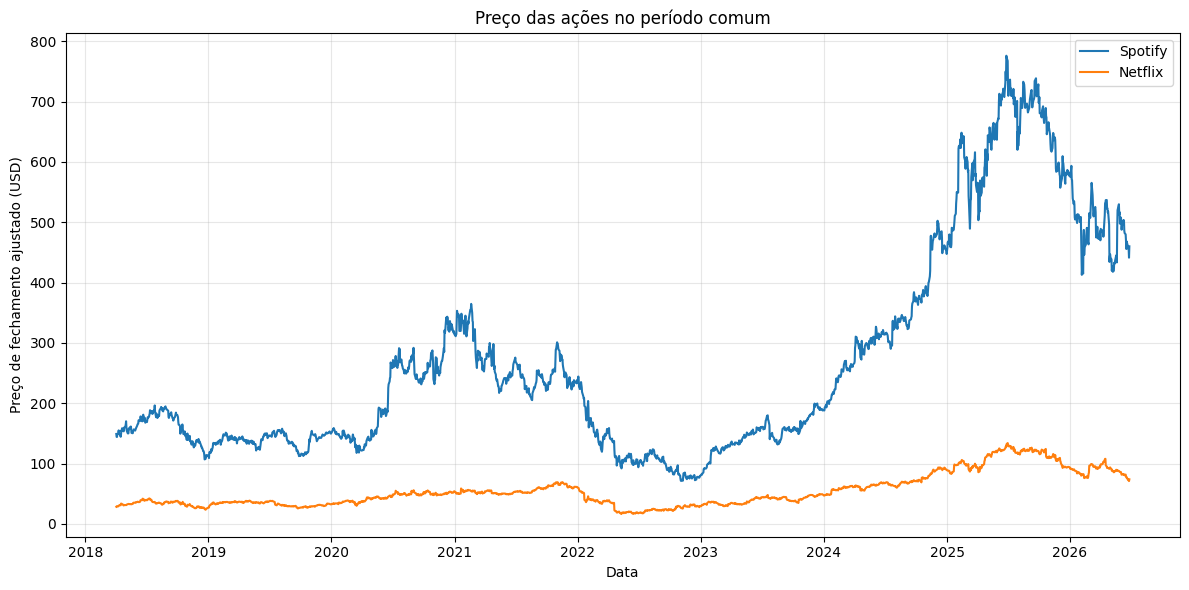

In [7]:
plt.figure(figsize=(12, 6))

plt.plot(
    spot_periodo_comum["Date"],
    spot_periodo_comum["Close"],
    label="Spotify"
)

plt.plot(
    nflx_periodo_comum["Date"],
    nflx_periodo_comum["Close"],
    label="Netflix"
)

plt.title("Preço das ações no período comum")
plt.xlabel("Data")
plt.ylabel("Preço de fechamento ajustado (USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Limitação da comparação por preços absolutos

O gráfico permite observar a evolução dos preços das duas ações durante o mesmo período. Entretanto, o valor nominal de uma ação não representa, isoladamente, seu desempenho.

Uma ação com preço mais elevado não necessariamente apresentou maior valorização, pois as empresas partiram de valores diferentes e podem ter passado por eventos como desdobramentos de ações.

Para comparar a variação relativa dos preços, eles serão normalizados utilizando o primeiro registro do período comum como base 100.


### Comparação normalizada dos preços

Para comparar o desempenho relativo das ações, o primeiro preço de fechamento disponível no período comum será definido como base 100 para ambas as empresas.

Assim, valores acima de 100 indicam valorização em relação ao início do período, enquanto valores abaixo de 100 indicam desvalorização.


In [8]:
# Consultando os preços no início e no fim do período comum
primeiro_preco_spotify = spot_periodo_comum["Close"].iloc[0]
ultimo_preco_spotify = spot_periodo_comum["Close"].iloc[-1]

primeiro_preco_netflix = nflx_periodo_comum["Close"].iloc[0]
ultimo_preco_netflix = nflx_periodo_comum["Close"].iloc[-1]

# Normalizando os preços com base 100
spot_periodo_comum["Close_normalizado"] = (
    spot_periodo_comum["Close"] / primeiro_preco_spotify
) * 100

nflx_periodo_comum["Close_normalizado"] = (
    nflx_periodo_comum["Close"] / primeiro_preco_netflix
) * 100

# Calculando a variação acumulada no período
variacao_spotify = (
    (ultimo_preco_spotify / primeiro_preco_spotify) - 1
) * 100

variacao_netflix = (
    (ultimo_preco_netflix / primeiro_preco_netflix) - 1
) * 100

# Criando um resumo numérico do desempenho
resumo_desempenho_acoes = pd.DataFrame({
    "Empresa": ["Spotify", "Netflix"],
    "Preço inicial (USD)": [
        primeiro_preco_spotify,
        primeiro_preco_netflix
    ],
    "Preço final (USD)": [
        ultimo_preco_spotify,
        ultimo_preco_netflix
    ],
    "Variação acumulada do preço (%)": [
        variacao_spotify,
        variacao_netflix
    ]
}).round(2)

display(resumo_desempenho_acoes)

,Empresa,Preço inicial (USD),Preço final (USD),Variação acumulada do preço (%)
0,Spotify,149.01,460.02,208.72
1,Netflix,28.37,73.81,160.20


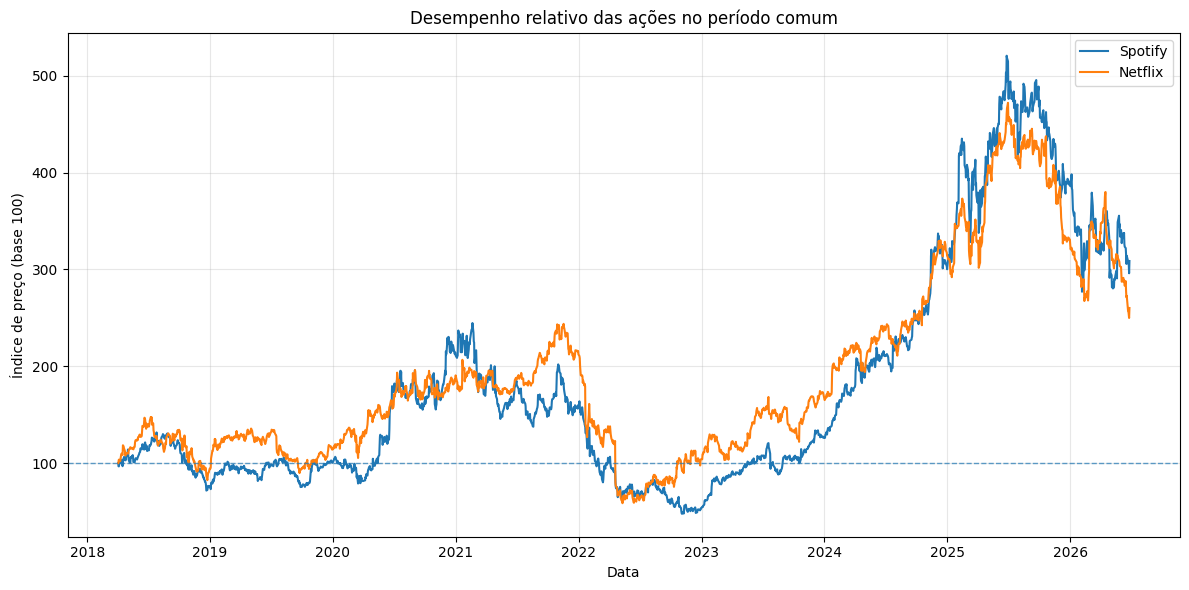

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    spot_periodo_comum["Date"],
    spot_periodo_comum["Close_normalizado"],
    label="Spotify"
)

plt.plot(
    nflx_periodo_comum["Date"],
    nflx_periodo_comum["Close_normalizado"],
    label="Netflix"
)

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

plt.title("Desempenho relativo das ações no período comum")
plt.xlabel("Data")
plt.ylabel("Índice de preço (base 100)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Análise do desempenho relativo das ações

Durante o período comum, entre 3 de abril de 2018 e 26 de junho de 2026, as ações das duas empresas encerraram acima de seus valores iniciais.

O preço ajustado da ação do Spotify passou de aproximadamente USD 149,01 para USD 460,02, o que representa uma variação acumulada de 208,72%. No mesmo período, a ação da Netflix passou de aproximadamente USD 28,37 para USD 73,81, acumulando variação de 160,20%.

Portanto, considerando somente a diferença entre o primeiro e o último preço do período analisado, o Spotify apresentou a maior variação acumulada.

O gráfico também mostra que essa vantagem não foi constante durante todo o período. As duas ações alternaram momentos de desempenho relativo superior e apresentaram queda acentuada em 2022, seguida por recuperação nos anos posteriores.

Essa comparação considera somente a evolução do preço ajustado das ações. Ela não avalia fatores como risco, volatilidade ou qualidade do investimento.


## 3. Análise das receitas

Além do preço das ações, será analisada a evolução das receitas anuais do Spotify e da Netflix.

Os valores absolutos serão apresentados separadamente, pois as empresas reportam seus resultados em moedas diferentes: euros no caso do Spotify e dólares no caso da Netflix.

Posteriormente, as receitas serão normalizadas para permitir a comparação de seu crescimento relativo durante o período disponível para ambas as empresas.


In [10]:
# Consultando as demonstrações financeiras anuais
spot_financials = spot.financials
nflx_financials = nflx.financials

# Selecionando a receita total do Spotify
spot_revenue = spot_financials.loc["Total Revenue"].dropna()
spot_revenue = spot_revenue.sort_index()
spot_revenue = spot_revenue.reset_index()
spot_revenue.columns = ["Date", "Revenue"]

# Selecionando a receita total da Netflix
nflx_revenue = nflx_financials.loc["Total Revenue"].dropna()
nflx_revenue = nflx_revenue.sort_index()
nflx_revenue = nflx_revenue.reset_index()
nflx_revenue.columns = ["Date", "Revenue"]

# Identificando as moedas utilizadas
moeda_spotify = spot.info["financialCurrency"]
moeda_netflix = nflx.info["financialCurrency"]

# Criando colunas auxiliares
spot_revenue["Year"] = spot_revenue["Date"].dt.year
nflx_revenue["Year"] = nflx_revenue["Date"].dt.year

spot_revenue["Revenue_billions"] = (
    spot_revenue["Revenue"] / 1_000_000_000
)

nflx_revenue["Revenue_billions"] = (
    nflx_revenue["Revenue"] / 1_000_000_000
)

In [11]:
# Resumo dos dados anuais de receita
resumo_receitas = pd.DataFrame({
    "Empresa": ["Spotify", "Netflix"],
    "Moeda": [moeda_spotify, moeda_netflix],
    "Ano inicial": [
        spot_revenue["Year"].min(),
        nflx_revenue["Year"].min()
    ],
    "Ano final": [
        spot_revenue["Year"].max(),
        nflx_revenue["Year"].max()
    ],
    "Registros anuais": [
        len(spot_revenue),
        len(nflx_revenue)
    ],
    "Valores ausentes": [
        spot_revenue["Revenue"].isna().sum(),
        nflx_revenue["Revenue"].isna().sum()
    ]
})

display(resumo_receitas)

,Empresa,Moeda,Ano inicial,Ano final,Registros anuais,Valores ausentes
0,Spotify,EUR,2022,2025,4,0
1,Netflix,USD,2022,2025,4,0


In [12]:
print("Receitas anuais do Spotify:")
display(
    spot_revenue[
        ["Year", "Revenue_billions"]
    ].rename(columns={
        "Year": "Ano",
        "Revenue_billions": "Receita (bilhões de EUR)"
    }).round(3)
)

print("\nReceitas anuais da Netflix:")
display(
    nflx_revenue[
        ["Year", "Revenue_billions"]
    ].rename(columns={
        "Year": "Ano",
        "Revenue_billions": "Receita (bilhões de USD)"
    }).round(3)
)

Receitas anuais do Spotify:


,Ano,Receita (bilhões de EUR)
0,2022,11.727
1,2023,13.247
2,2024,15.673
3,2025,17.186



Receitas anuais da Netflix:


,Ano,Receita (bilhões de USD)
0,2022,31.616
1,2023,33.723
2,2024,39.001
3,2025,45.183


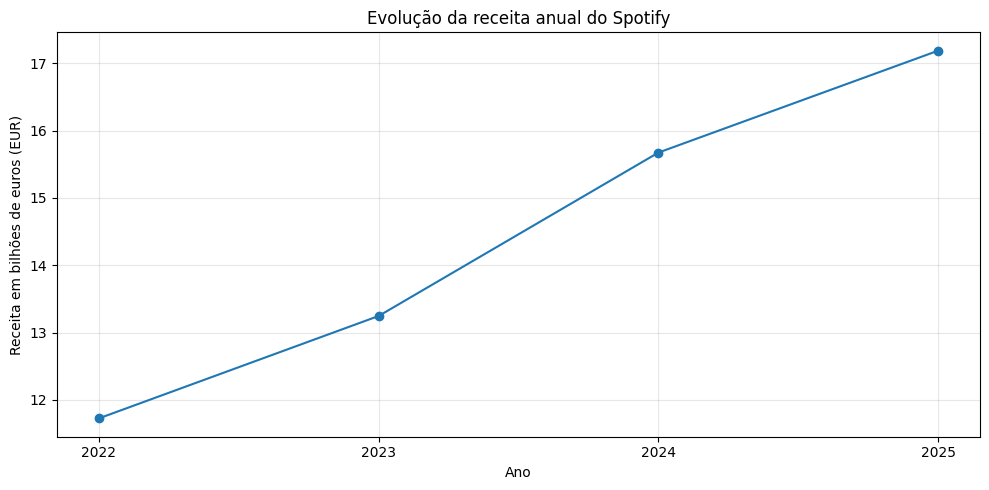

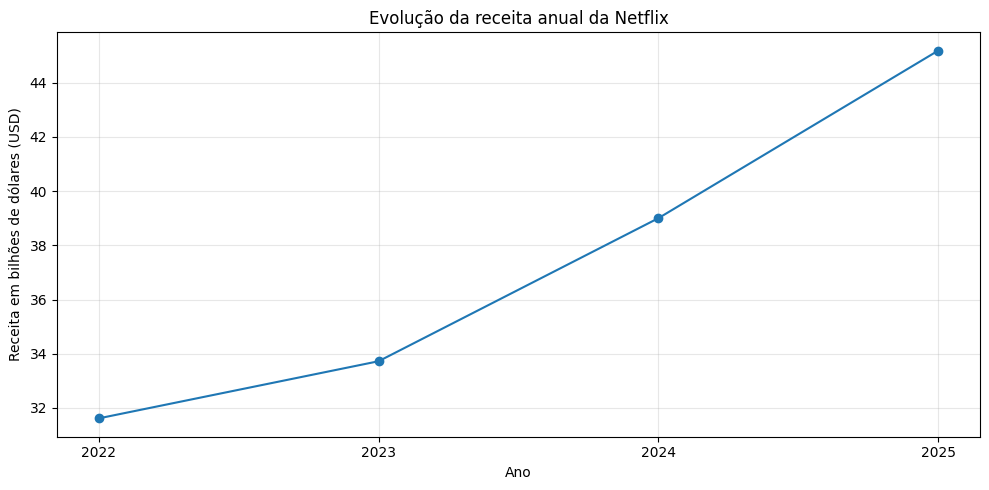

In [13]:
# Receita anual do Spotify
plt.figure(figsize=(10, 5))

plt.plot(
    spot_revenue["Year"],
    spot_revenue["Revenue_billions"],
    marker="o"
)

plt.title("Evolução da receita anual do Spotify")
plt.xlabel("Ano")
plt.ylabel("Receita em bilhões de euros (EUR)")
plt.xticks(spot_revenue["Year"])
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()


# Receita anual da Netflix
plt.figure(figsize=(10, 5))

plt.plot(
    nflx_revenue["Year"],
    nflx_revenue["Revenue_billions"],
    marker="o"
)

plt.title("Evolução da receita anual da Netflix")
plt.xlabel("Ano")
plt.ylabel("Receita em bilhões de dólares (USD)")
plt.xticks(nflx_revenue["Year"])
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Evolução das receitas em valores absolutos

Os dados disponíveis mostram crescimento contínuo das receitas das duas empresas entre 2022 e 2025.

A receita anual do Spotify passou de aproximadamente € 11,7 bilhões para € 17,2 bilhões. No mesmo intervalo, a receita da Netflix passou de aproximadamente USD 31,6 bilhões para USD 45,2 bilhões.

Os gráficos são apresentados separadamente porque as empresas divulgam seus resultados em moedas diferentes. Portanto, os valores absolutos não devem ser utilizados diretamente para concluir qual empresa apresentou maior crescimento relativo.

Além disso, a consulta retornou somente quatro registros anuais para cada empresa, o que permite identificar uma tendência recente, mas limita conclusões de longo prazo.


,Empresa,Ano inicial,Ano final,Receita inicial (bilhões),Receita final (bilhões),Moeda,Variação acumulada da receita (%)
0,Spotify,2022,2025,11.73,17.19,EUR,46.55
1,Netflix,2022,2025,31.62,45.18,USD,42.91


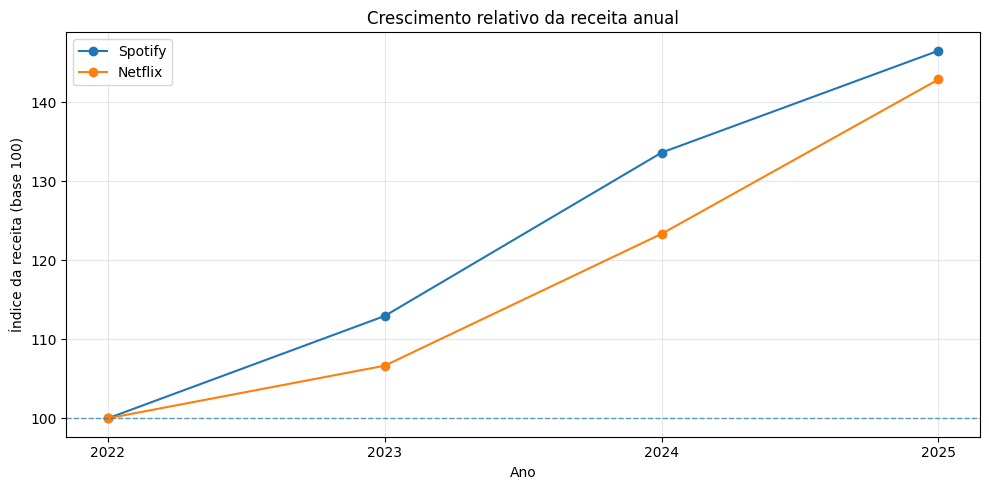

In [14]:
# Identificando os anos disponíveis para as duas empresas
anos_comuns = sorted(
    set(spot_revenue["Year"]).intersection(
        set(nflx_revenue["Year"])
    )
)

# Mantendo somente os anos comuns
spot_revenue_comum = spot_revenue[
    spot_revenue["Year"].isin(anos_comuns)
].sort_values("Year").copy()

nflx_revenue_comum = nflx_revenue[
    nflx_revenue["Year"].isin(anos_comuns)
].sort_values("Year").copy()

# Consultando as receitas no início e no fim do período comum
primeira_receita_spotify = (
    spot_revenue_comum["Revenue_billions"].iloc[0]
)

ultima_receita_spotify = (
    spot_revenue_comum["Revenue_billions"].iloc[-1]
)

primeira_receita_netflix = (
    nflx_revenue_comum["Revenue_billions"].iloc[0]
)

ultima_receita_netflix = (
    nflx_revenue_comum["Revenue_billions"].iloc[-1]
)

# Normalizando as receitas com base 100
spot_revenue_comum["Revenue_normalized"] = (
    spot_revenue_comum["Revenue_billions"]
    / primeira_receita_spotify
) * 100

nflx_revenue_comum["Revenue_normalized"] = (
    nflx_revenue_comum["Revenue_billions"]
    / primeira_receita_netflix
) * 100

# Calculando a variação acumulada das receitas
variacao_receita_spotify = (
    (ultima_receita_spotify / primeira_receita_spotify) - 1
) * 100

variacao_receita_netflix = (
    (ultima_receita_netflix / primeira_receita_netflix) - 1
) * 100

# Criando um resumo numérico
resumo_crescimento_receitas = pd.DataFrame({
    "Empresa": ["Spotify", "Netflix"],
    "Ano inicial": [anos_comuns[0], anos_comuns[0]],
    "Ano final": [anos_comuns[-1], anos_comuns[-1]],
    "Receita inicial (bilhões)": [
        primeira_receita_spotify,
        primeira_receita_netflix
    ],
    "Receita final (bilhões)": [
        ultima_receita_spotify,
        ultima_receita_netflix
    ],
    "Moeda": [
        moeda_spotify,
        moeda_netflix
    ],
    "Variação acumulada da receita (%)": [
        variacao_receita_spotify,
        variacao_receita_netflix
    ]
}).round(2)

display(resumo_crescimento_receitas)

# Gráfico do crescimento relativo
plt.figure(figsize=(10, 5))

plt.plot(
    spot_revenue_comum["Year"],
    spot_revenue_comum["Revenue_normalized"],
    marker="o",
    label="Spotify"
)

plt.plot(
    nflx_revenue_comum["Year"],
    nflx_revenue_comum["Revenue_normalized"],
    marker="o",
    label="Netflix"
)

plt.axhline(
    y=100,
    linestyle="--",
    linewidth=1,
    alpha=0.7
)

plt.title("Crescimento relativo da receita anual")
plt.xlabel("Ano")
plt.ylabel("Índice da receita (base 100)")
plt.xticks(anos_comuns)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.show()

### Análise do crescimento relativo das receitas

Entre 2022 e 2025, as duas empresas apresentaram crescimento contínuo de receita.

A receita anual do Spotify passou de aproximadamente € 11,73 bilhões para € 17,19 bilhões, resultando em uma variação acumulada de 46,55%. No mesmo período, a receita da Netflix passou de aproximadamente USD 31,62 bilhões para USD 45,18 bilhões, com variação acumulada de 42,91%.

Portanto, considerando o crescimento relativo entre o primeiro e o último ano disponível, o Spotify apresentou a maior variação acumulada da receita, superando a Netflix em aproximadamente 3,64 pontos percentuais.

Embora a Netflix apresente valores absolutos de receita mais elevados, esses números não devem ser comparados diretamente, pois as empresas reportam seus resultados em moedas diferentes. A normalização em base 100 permite comparar apenas o ritmo de crescimento das receitas.

A análise está limitada aos quatro registros anuais retornados pela fonte de dados, entre 2022 e 2025. Dessa forma, os resultados representam uma comparação recente e não necessariamente uma tendência de longo prazo.


## 4. Conclusões

A análise comparou a evolução dos preços das ações e das receitas anuais do Spotify e da Netflix, utilizando períodos comuns e valores normalizados para tornar as comparações mais consistentes.

### 1. Como os preços das ações evoluíram?

Durante o período comum, entre abril de 2018 e junho de 2026, as ações das duas empresas apresentaram oscilações relevantes, incluindo uma queda acentuada em 2022 e recuperação nos anos posteriores.

Apesar dessas variações ao longo do período, Spotify e Netflix terminaram a análise com preços ajustados superiores aos valores iniciais.

### 2. Qual ação apresentou maior variação acumulada?

O preço ajustado da ação do Spotify passou de aproximadamente USD 149,01 para USD 460,02, correspondendo a uma variação acumulada de 208,72%.

No mesmo período, a ação da Netflix passou de aproximadamente USD 28,37 para USD 73,81, apresentando variação acumulada de 160,20%.

Portanto, considerando somente a diferença entre o primeiro e o último preço do período comum, o Spotify apresentou a maior variação acumulada do preço da ação.

### 3. Como as receitas anuais evoluíram?

Entre 2022 e 2025, as duas empresas apresentaram crescimento contínuo de receita.

A receita anual do Spotify passou de aproximadamente € 11,73 bilhões para € 17,19 bilhões. A receita da Netflix passou de aproximadamente USD 31,62 bilhões para USD 45,18 bilhões.

Como os valores são reportados em moedas diferentes, os montantes absolutos foram apresentados separadamente.

### 4. Qual empresa apresentou maior crescimento relativo de receita?

Após a normalização das receitas utilizando o primeiro ano como base 100, o Spotify apresentou uma variação acumulada de 46,55%, enquanto a Netflix apresentou uma variação de 42,91%.

Assim, o Spotify registrou o maior crescimento relativo da receita no período analisado, com uma diferença de aproximadamente 3,64 pontos percentuais.

## Limitações da análise

Os resultados estão sujeitos a algumas limitações:

* os dados foram obtidos por meio da biblioteca `yfinance`;
* a análise das ações considera somente a evolução do preço ajustado, sem avaliar risco, volatilidade ou outros indicadores financeiros;
* a consulta realizada por meio do `yfinance` retornou quatro registros anuais de receita, entre 2022 e 2025;
* as empresas reportam suas receitas em moedas diferentes;
* a análise é descritiva e não busca explicar as causas das variações observadas.


